# K-Means Clustering Analysis — Bank Data

This notebook is a corrected and improved version of the K-Means clustering analysis for the given bank dataset.

## Main corrections made

1. Corrected the dataset loading path.
2. Excluded `Bank` from clustering because it is an ID column, not a behavioral feature.
3. Added proper duplicate, missing-value, and outlier checks.
4. Applied outlier capping only to analytical features.
5. Standardized the features before K-Means.
6. Used `random_state` and `n_init` for reproducible clustering.
7. Removed repeated/unnecessary model fitting.
8. Added elbow method, silhouette score, Davies-Bouldin score, and Calinski-Harabasz score.
9. Added cluster profiling, observations, and conclusion.

In [1]:
# Import required libraries
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

In [2]:
# Load the dataset
# Keep the CSV file in the same folder as this notebook.
possible_paths = [
    Path("bank data.csv"),
    Path("bank.csv"),
    Path("/mnt/data/bank data.csv")
]

data_path = None
for path in possible_paths:
    if path.exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError("Dataset not found. Please keep 'bank data.csv' in the same folder as this notebook.")

bank_df = pd.read_csv(data_path)
print(f"Dataset loaded from: {data_path}")
bank_df.head()

Dataset loaded from: /mnt/data/bank data.csv


,Bank,DD,Withdrawals,Deposits,Branch Area in sqft,avg daily walkins
0,1,227,147,111,2460,639
1,2,123,86,65,3510,436
2,3,306,149,76,2570,669
3,4,251,112,129,3650,623
4,5,174,135,128,3400,579


## 1. Basic data inspection

In [3]:
# Shape of the dataset
bank_df.shape

(515, 6)

In [4]:
# Column information and data types
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Bank                 515 non-null    int64
 1   DD                   515 non-null    int64
 2   Withdrawals          515 non-null    int64
 3   Deposits             515 non-null    int64
 4   Branch Area in sqft  515 non-null    int64
 5   avg daily walkins    515 non-null    int64
dtypes: int64(6)
memory usage: 24.3 KB


In [5]:
# Summary statistics
bank_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Bank,515.0,258.000000,148.811962,1.0,129.5,258.0,386.5,515.0
DD,515.0,232.252427,66.648815,120.0,169.5,237.0,291.0,350.0
Withdrawals,515.0,150.693204,56.897777,10.0,103.0,152.0,200.0,247.0
Deposits,515.0,81.687379,28.596912,33.0,58.0,80.0,105.0,212.0
Branch Area in sqft,515.0,2934.669903,437.062831,1200.0,2675.0,2960.0,3300.0,3650.0
avg daily walkins,515.0,598.603883,83.487891,380.0,537.5,601.0,657.5,838.0


In [6]:
# Check duplicate rows
bank_df.duplicated().sum()

np.int64(0)

In [7]:
# Check missing values
bank_df.isna().sum()

Bank                   0
DD                     0
Withdrawals            0
Deposits               0
Branch Area in sqft    0
avg daily walkins      0
dtype: int64

## 2. Select features for clustering

`Bank` is an identifier column. It should not be used for clustering because it does not describe bank branch behavior or performance.

In [8]:
# Exclude the ID column from clustering
id_column = "Bank"
feature_columns = [col for col in bank_df.columns if col != id_column]

X_original = bank_df[feature_columns].copy()
feature_columns

['DD', 'Withdrawals', 'Deposits', 'Branch Area in sqft', 'avg daily walkins']

## 3. Outlier detection

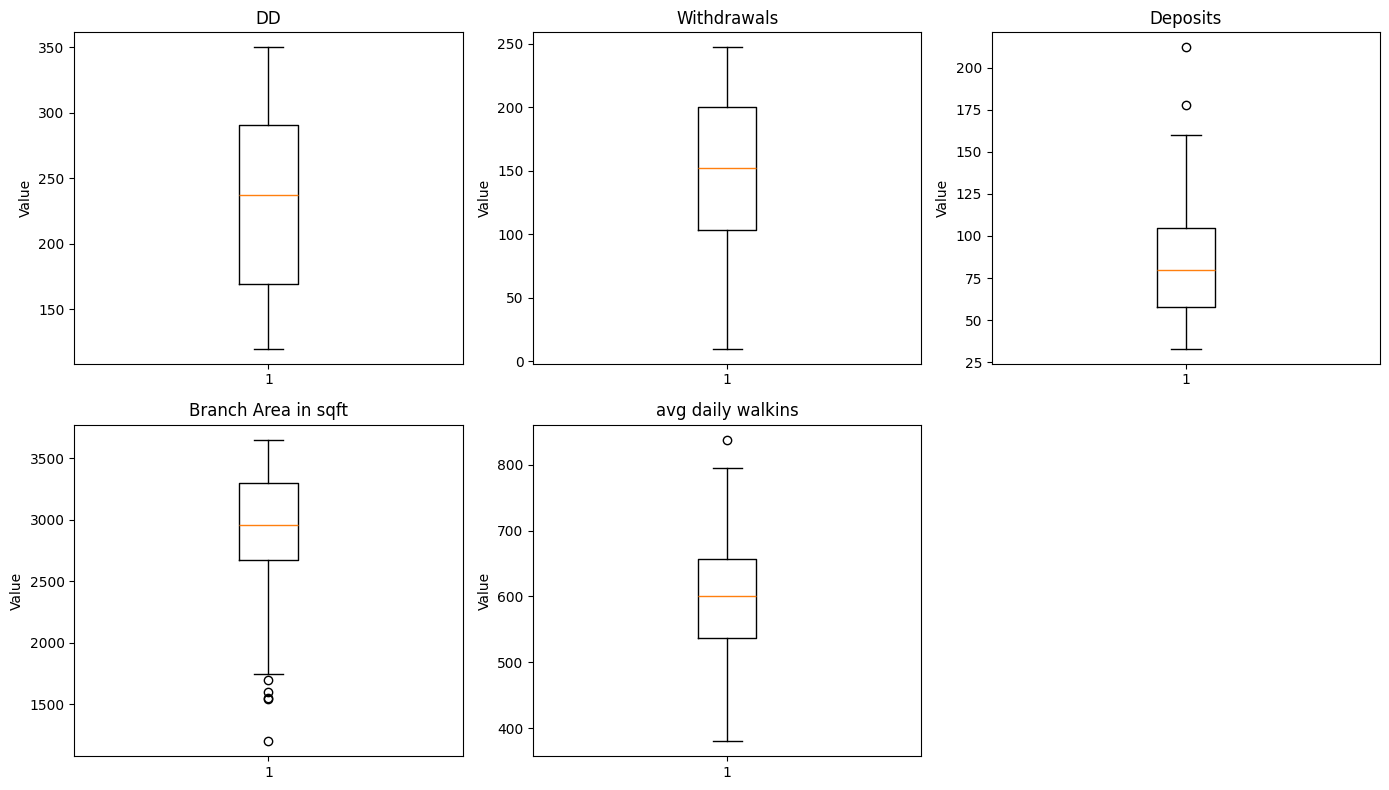

In [9]:
# Boxplots before outlier treatment
plt.figure(figsize=(14, 8))
for i, col in enumerate(feature_columns, 1):
    plt.subplot(2, 3, i)
    plt.boxplot(X_original[col], vert=True)
    plt.title(col)
    plt.ylabel("Value")
plt.tight_layout()
plt.show()

In [10]:
# IQR outlier summary
outlier_summary = []

for col in feature_columns:
    q1 = X_original[col].quantile(0.25)
    q3 = X_original[col].quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    outlier_count = ((X_original[col] < lower_limit) | (X_original[col] > upper_limit)).sum()
    outlier_summary.append([col, lower_limit, upper_limit, outlier_count])

outlier_summary_df = pd.DataFrame(
    outlier_summary,
    columns=["Feature", "Lower Limit", "Upper Limit", "Outlier Count"]
)
outlier_summary_df

,Feature,Lower Limit,Upper Limit,Outlier Count
0,DD,-12.75,473.25,0
1,Withdrawals,-42.50,345.50,0
2,Deposits,-12.50,175.50,2
3,Branch Area in sqft,1737.50,4237.50,5
4,avg daily walkins,357.50,837.50,1


## 4. Outlier treatment

The outliers are capped using the IQR method. Capping is preferred here because we do not want to unnecessarily remove branch records from a small business dataset.

In [11]:
# Cap outliers using IQR method
X_capped = X_original.copy()

def cap_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    return series.clip(lower=lower_limit, upper=upper_limit)

for col in feature_columns:
    X_capped[col] = cap_outliers_iqr(X_capped[col])

X_capped.describe().T

,count,mean,std,min,25%,50%,75%,max
DD,515.0,232.252427,66.648815,120.0,169.5,237.0,291.0,350.0
Withdrawals,515.0,150.693204,56.897777,10.0,103.0,152.0,200.0,247.0
Deposits,515.0,81.611650,28.300838,33.0,58.0,80.0,105.0,175.5
Branch Area in sqft,515.0,2936.800971,430.303453,1737.5,2675.0,2960.0,3300.0,3650.0
avg daily walkins,515.0,598.602913,83.485105,380.0,537.5,601.0,657.5,837.5


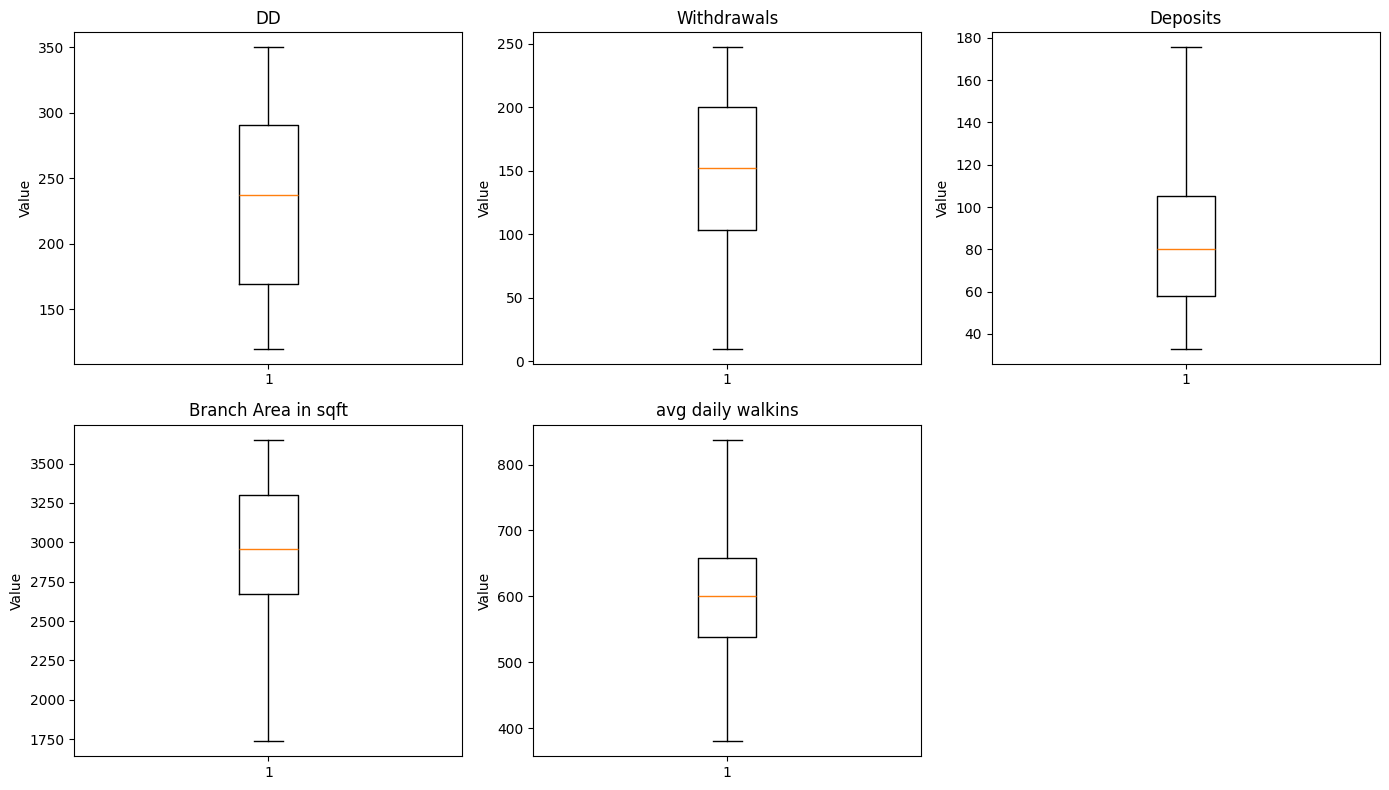

In [12]:
# Boxplots after outlier treatment
plt.figure(figsize=(14, 8))
for i, col in enumerate(feature_columns, 1):
    plt.subplot(2, 3, i)
    plt.boxplot(X_capped[col], vert=True)
    plt.title(col)
    plt.ylabel("Value")
plt.tight_layout()
plt.show()

## 5. Feature scaling

K-Means is distance-based. Therefore, all features are standardized before clustering.

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_capped)

scaled_df = pd.DataFrame(X_scaled, columns=feature_columns)
scaled_df.head()

,DD,Withdrawals,Deposits,Branch Area in sqft,avg daily walkins
0,-0.078884,-0.064973,1.039436,-1.109135,0.484354
1,-1.640819,-1.138113,-0.587537,1.333376,-1.949581
2,1.107586,-0.029788,-0.198478,-0.853253,0.844049
3,0.281562,-0.680709,1.676078,1.659044,0.292517
4,-0.874870,-0.276082,1.640709,1.077494,-0.235036


## 6. Find a suitable number of clusters

We compare multiple values of K using:

- Inertia / WSS for the elbow method
- Silhouette score
- Davies-Bouldin score
- Calinski-Harabasz score

In [14]:
cluster_metrics = []
inertia_values = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    inertia_values.append(model.inertia_)
    
    if k == 1:
        cluster_metrics.append([k, model.inertia_, np.nan, np.nan, np.nan])
    else:
        cluster_metrics.append([
            k,
            model.inertia_,
            silhouette_score(X_scaled, labels),
            davies_bouldin_score(X_scaled, labels),
            calinski_harabasz_score(X_scaled, labels)
        ])

metrics_df = pd.DataFrame(
    cluster_metrics,
    columns=["K", "Inertia/WSS", "Silhouette Score", "Davies-Bouldin Score", "Calinski-Harabasz Score"]
)
metrics_df.round(4)

,K,Inertia/WSS,Silhouette Score,Davies-Bouldin Score,Calinski-Harabasz Score
0,1,2575.0000,NaN,NaN,NaN
1,2,1943.2011,0.2181,1.6789,166.7932
2,3,1592.9913,0.2180,1.4557,157.8127
3,4,1375.0866,0.2263,1.3972,148.6345
4,5,1218.5485,0.2308,1.2767,141.9292
5,6,1117.8802,0.2319,1.2376,132.6929
6,7,1024.0231,0.2238,1.2660,128.2354
7,8,943.8456,0.2199,1.3195,125.1711
8,9,890.7525,0.2109,1.3367,119.5940
9,10,836.4909,0.2101,1.2801,116.6177


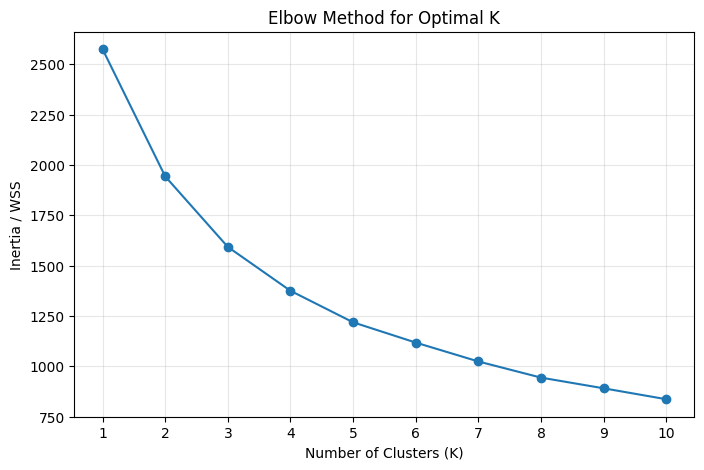

In [15]:
# Elbow plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia_values, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia / WSS")
plt.title("Elbow Method for Optimal K")
plt.xticks(range(1, 11))
plt.grid(True, alpha=0.3)
plt.show()

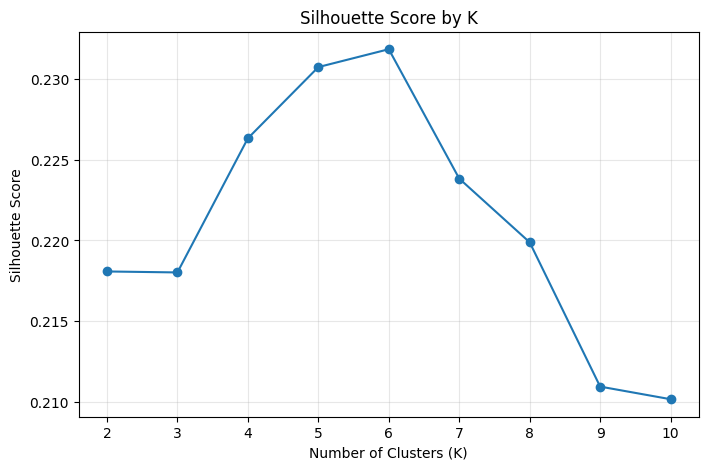

In [16]:
# Silhouette score plot
plt.figure(figsize=(8, 5))
plt.plot(metrics_df["K"][1:], metrics_df["Silhouette Score"][1:], marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by K")
plt.xticks(range(2, 11))
plt.grid(True, alpha=0.3)
plt.show()

## 7. Final K-Means model

Based on the elbow curve and validation metrics, `K = 4` gives a reasonable balance between interpretability and cluster quality for this dataset.

The silhouette values are not very high, so the clusters should be interpreted as business segments rather than perfectly separated groups.

In [17]:
FINAL_K = 4

kmeans_final = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

clustered_df = bank_df.copy()
clustered_df["Cluster"] = cluster_labels

clustered_df.head()

,Bank,DD,Withdrawals,Deposits,Branch Area in sqft,avg daily walkins,Cluster
0,1,227,147,111,2460,639,1
1,2,123,86,65,3510,436,3
2,3,306,149,76,2570,669,1
3,4,251,112,129,3650,623,0
4,5,174,135,128,3400,579,3


In [18]:
# Final model scores
final_scores = {
    "Final K": FINAL_K,
    "Inertia/WSS": kmeans_final.inertia_,
    "Silhouette Score": silhouette_score(X_scaled, cluster_labels),
    "Davies-Bouldin Score": davies_bouldin_score(X_scaled, cluster_labels),
    "Calinski-Harabasz Score": calinski_harabasz_score(X_scaled, cluster_labels)
}

pd.DataFrame([final_scores]).round(4)

,Final K,Inertia/WSS,Silhouette Score,Davies-Bouldin Score,Calinski-Harabasz Score
0,4,1375.0866,0.2263,1.3972,148.6345


## 8. Cluster profile

The table below shows the average values of each feature in every cluster. This helps explain what each cluster represents.

In [19]:
cluster_profile = clustered_df.groupby("Cluster")[feature_columns].mean().round(2)
cluster_profile

,DD,Withdrawals,Deposits,Branch Area in sqft,avg daily walkins
Cluster,,,,,
0,290.88,105.22,72.66,3115.76,601.39
1,278.38,192.37,88.99,2603.03,693.42
2,177.20,194.00,73.03,3020.14,578.81
3,168.98,94.54,97.55,2997.19,496.43


In [20]:
# Cluster size
cluster_size = clustered_df["Cluster"].value_counts().sort_index().rename("Number of Branches")
cluster_size.to_frame()

,Number of Branches
Cluster,
0,139
1,132
2,146
3,98


In [21]:
# Combined cluster summary
cluster_summary = cluster_profile.copy()
cluster_summary.insert(0, "Number of Branches", cluster_size)
cluster_summary

,Number of Branches,DD,Withdrawals,Deposits,Branch Area in sqft,avg daily walkins
Cluster,,,,,,
0,139,290.88,105.22,72.66,3115.76,601.39
1,132,278.38,192.37,88.99,2603.03,693.42
2,146,177.20,194.00,73.03,3020.14,578.81
3,98,168.98,94.54,97.55,2997.19,496.43


## 9. Visualize clusters using PCA

PCA is used only for 2D visualization. The K-Means model itself was trained on all standardized features.

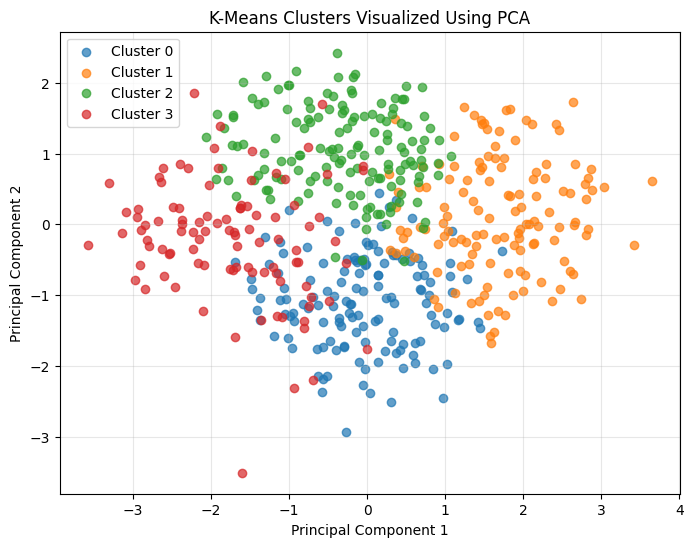

Variance explained by first 2 principal components: 61.04%


In [22]:
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(pca_components, columns=["PC1", "PC2"])
pca_df["Cluster"] = cluster_labels

plt.figure(figsize=(8, 6))
for cluster in sorted(pca_df["Cluster"].unique()):
    subset = pca_df[pca_df["Cluster"] == cluster]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Cluster {cluster}", alpha=0.7)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters Visualized Using PCA")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

explained_variance = pca.explained_variance_ratio_.sum()
print(f"Variance explained by first 2 principal components: {explained_variance:.2%}")

## 10. Observations

From the final cluster profile:

- **Cluster 0**: Branches with high DD, low withdrawals, moderate walk-ins, and relatively larger branch area.
- **Cluster 1**: Branches with high DD, high withdrawals, high walk-ins, and smaller branch area. These appear to be high-activity branches.
- **Cluster 2**: Branches with lower DD but high withdrawals and moderate walk-ins.
- **Cluster 3**: Branches with lower DD, lower withdrawals, relatively higher deposits, and lower walk-ins.

The exact cluster numbering may change if the model settings are changed, but the branch segments remain based on differences in transaction activity, deposits, branch area, and walk-ins.

## 11. Conclusion

The bank branches were segmented using K-Means clustering after cleaning, outlier capping, and standardizing the numerical features. The `Bank` column was excluded because it is only an identifier and should not influence clustering.

The analysis suggests that the branches can be grouped into **4 meaningful segments** based on DD, withdrawals, deposits, branch size, and daily walk-ins. These segments can help the bank compare branch behavior, identify high-activity branches, and understand branches with low customer footfall or different transaction patterns.

The silhouette score is modest, so the clusters are useful for exploratory business segmentation, but they are not extremely well-separated. Further improvement can be done by adding more customer, revenue, location, or product-level variables.

In [23]:
# Save clustered output for further use
output_csv = "bank_data_with_kmeans_clusters.csv"
clustered_df.to_csv(output_csv, index=False)
print(f"Clustered dataset saved as: {output_csv}")

Clustered dataset saved as: bank_data_with_kmeans_clusters.csv
